<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Anti002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

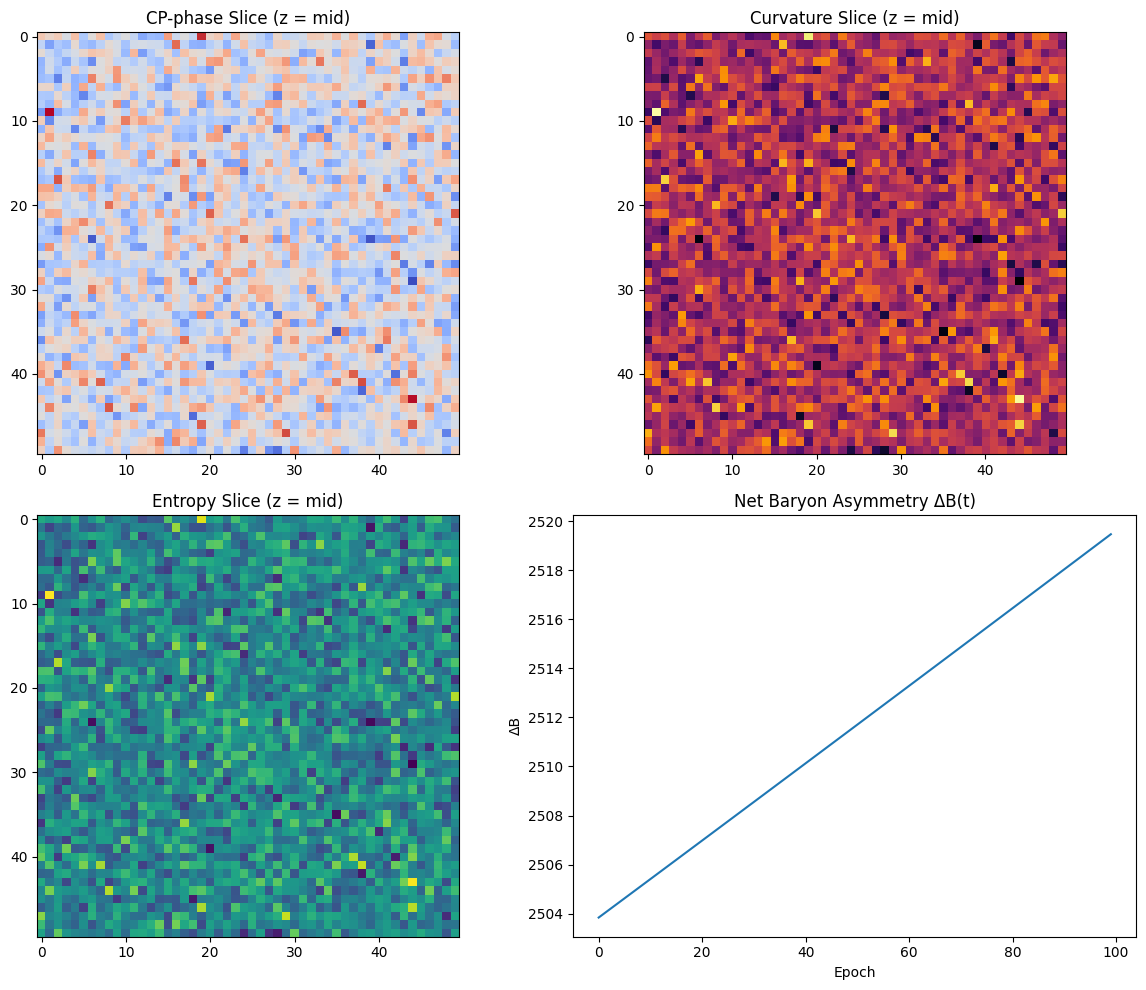

In [ ]:
# HES CP-Violation Simulation in 3D
import numpy as np
import matplotlib.pyplot as plt

# Lattice parameters
N = 50  # 3D lattice size (adjustable)
epochs = 100
phi_cp = np.random.normal(loc=0.01, scale=0.005, size=(N, N, N))  # CP-phase bias
kappa = np.zeros((N, N, N))  # curvature field
entropy = np.ones((N, N, N))  # initial entropy
delta_B = []  # net baryon asymmetry over time

# Feedback function
def update_fields(phi_cp, kappa, entropy):
    xi = phi_cp * (1 + kappa)
    kappa += 0.01 * xi
    entropy += 0.005 * xi
    return kappa, entropy

# Baryon asymmetry metric
def compute_asymmetry(phi_cp, entropy):
    rho_matter = entropy * (1 + phi_cp)
    rho_antimatter = entropy * (1 - phi_cp)
    return np.sum(rho_matter - rho_antimatter)

# Simulation loop
for t in range(epochs):
    kappa, entropy = update_fields(phi_cp, kappa, entropy)
    delta_B.append(compute_asymmetry(phi_cp, entropy))

# Visualization: central slices
mid = N // 2
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

axs[0, 0].imshow(phi_cp[:, :, mid], cmap='coolwarm')
axs[0, 0].set_title("CP-phase Slice (z = mid)")

axs[0, 1].imshow(kappa[:, :, mid], cmap='inferno')
axs[0, 1].set_title("Curvature Slice (z = mid)")

axs[1, 0].imshow(entropy[:, :, mid], cmap='viridis')
axs[1, 0].set_title("Entropy Slice (z = mid)")

axs[1, 1].plot(delta_B)
axs[1, 1].set_title("Net Baryon Asymmetry ΔB(t)")
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("ΔB")

plt.tight_layout()
plt.show()
